In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
# Make sure creditcard.csv is in the same folder
df = pd.read_csv('creditcard.csv')

# Inspect the first few rows
print(df.head())

# Check the shape (Rows, Columns)
print(f"Dataset Shape: {df.shape}")

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [2]:
# 1. Check for missing values
print("Missing Values:\n", df.isnull().sum().max()) 
# If output is 0, explicitly state in your notebook: "No missing values found."

# 2. Check data types to ensure everything is numerical
print(df.info())

# 3. Check for duplicates and remove them
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

Missing Values:
 0
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V2

Class
0    283253
1       473
Name: count, dtype: int64


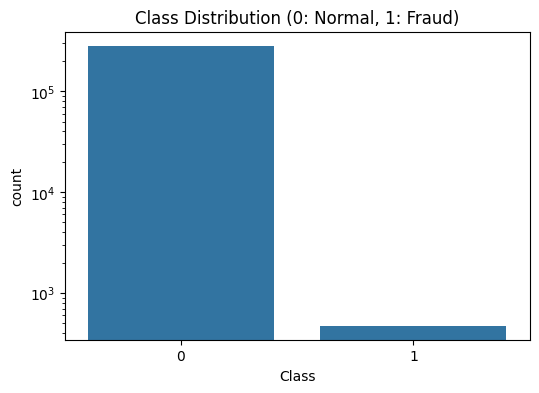

In [ ]:
#A.Count the occurrences of fraud and non-fraud cases
class_counts = df['Class'].value_counts()
print(class_counts)

# Visualize the imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.yscale('log') # Log scale helps visualize the small number of frauds
plt.show()

Fraud Transaction Stats:
count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal Transaction Stats:
count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64


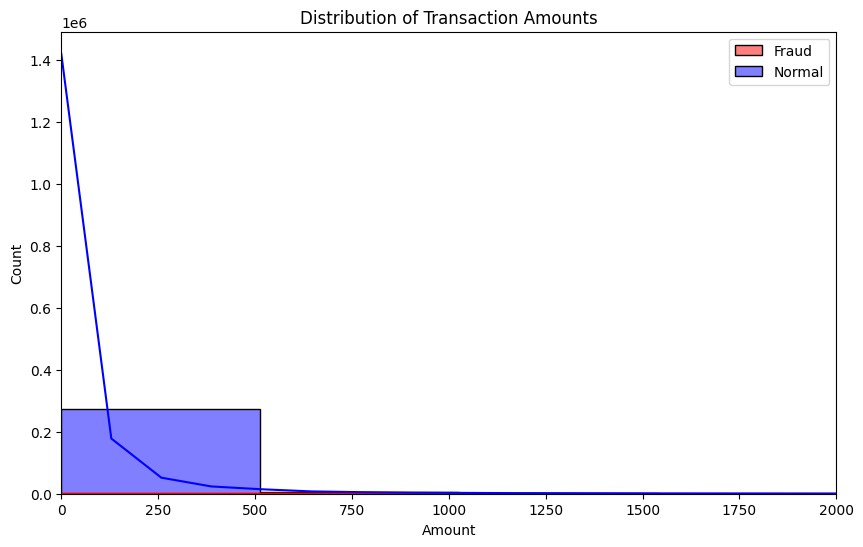

In [ ]:
#B.Statistical summary of the 'Amount' column for Fraud vs Normal
print("Fraud Transaction Stats:")
print(df[df['Class'] == 1]['Amount'].describe())

print("\nNormal Transaction Stats:")
print(df[df['Class'] == 0]['Amount'].describe())

# Visualizing Amount Distribution
plt.figure(figsize=(10,6))
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', label='Fraud', kde=True)
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', label='Normal', kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlim(0, 2000) # Limiting x-axis to zoom in on common amounts
plt.legend()
plt.show()

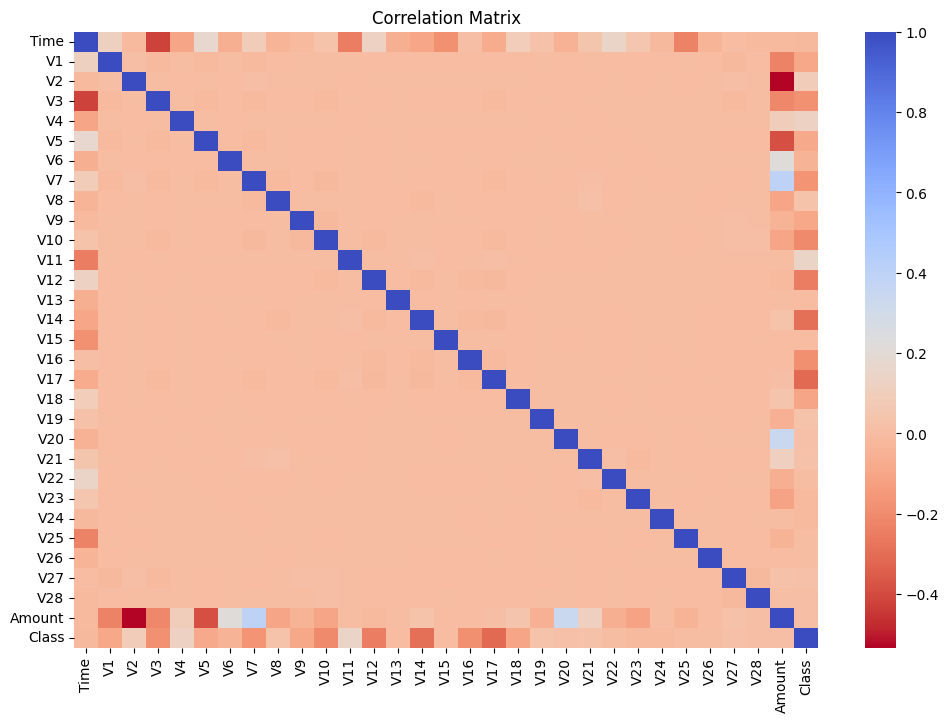

In [ ]:
# C
plt.figure(figsize=(12,8))
corr = df.corr()
# We only want to see strong correlations, so we can mask weak ones or just plot the whole thing
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20})
plt.title('Correlation Matrix')
plt.show()